# 34_01 — Simulación y preprocesamiento · Escenario K (heterocedasticidad condicional en tau)

Escenario de **diagnóstico** (no es un Algoritmo del anexo), implementado en
`pipelines/sim_escenario_K.py`. La media condicional es la del **Algoritmo 1**
sin cambios; lo que este escenario interviene es el canal de **varianza**:

$$Y_t(\tau) = (\Psi Y_{t-1})(\tau) + s(\tau; z_{t-1})\, \xi_t(\tau), \qquad
  s(\tau; z) = \sqrt{1 + \kappa\, \tanh(z/\text{sd}_z)\, v(\tau)},$$

con $z_{t-1} = \langle Y_{t-1}, e\rangle_{L^2}$ el nivel de la curva rezagada,
$v(\tau) = \cos(2\pi\tau)$ (más varianza en los EXTREMOS del
dominio, menos en el CENTRO) y $\xi_t$ la innovación gaussiana correlacionada
de siempre. Cuando $z_{t-1}>0$ la varianza se concentra en los extremos;
cuando $z_{t-1}<0$, en el centro — una conmutación ANTISIMÉTRICA de la FORMA
de la varianza en $\tau$, análoga en el canal de varianza a lo que el
Escenario B hace en el canal de media.

**Ningún escenario del estudio produce esto.** El Algoritmo 2 (FGARCH) modula
un factor de volatilidad ESCALAR que multiplica toda la curva por igual; el
resto es homocedástico en $\tau$. Este escenario existe para poner a prueba si
`PropagadorFuncional` —cuya banda en $\tau$ para un origen dado es siempre una
combinación lineal fija $\sum_m w_m\, \psi_m(\tau)^2$ de las autofunciones ya
estimadas, más un residuo de representación que ni siquiera depende del
rezago— puede reproducir un patrón de varianza en $\tau$ que cambia de FORMA
según el signo del estado anterior.

**Como la media condicional es exactamente la del Algoritmo 1, el MISE NO
discrimina aquí** (por diseño: es el mismo argumento que hace que el
Algoritmo 2 no discrimine en RMSE/R²). El eje que este escenario existe para
medir es exclusivamente CRPS, energía y — sobre todo — la **cobertura
condicional en el signo de $z_{t-1}$**, estratificando el `_04` por esa
variable en vez de por un estado latente continuo cuantilizado.

`N_LAGS = 1` es exacto aquí, no una concesión de comparabilidad: la dinámica
es de un solo rezago, igual que el Algoritmo 1 y que todos los demás
escenarios de un solo rezago del estudio.

Los parámetros del generador (`ConfigEscenarioK`) se usan **con sus defaults
validados**, sin overrides: `gamma=0.30`, `hs_norm=0.70` (idénticos al
Algoritmo 1, a propósito, para que la media condicional sea indistinguible),
`sigma_eps=1.0`, `ell=0.5`, `kappa=0.90`, `nitidez=5.0` — ver el docstring de
`ConfigEscenarioK` para la justificación de cada uno. Sólo se fija el esquema
de observación (`L`, `T`, `burn_in`, `sigma_obs`, `R`, `seed`, `media_fn`),
como en las corridas 30–33.

Diagnóstico verificado del generador con estos parámetros (`seed=41232`,
`L=75`, `T=400`, `R=1`, ejecutado como prueba fuera de este notebook):

| Cantidad | Valor |
|---|---|
| `contractividad` / `positividad_garantizada` | `True` / `True` |
| `razon_escala_cuadrado_extremos_centro_zpos` | ~7.07 (contraste INSTANTÁNEO, no diluido por Psi) |
| `razon_escala_cuadrado_extremos_centro_zneg` | ~0.14 |
| `razon_varianza_extremos_centro_zpos` | ~3.63 (sobre la curva REALIZADA, con la memoria de `Psi`) |
| `razon_varianza_extremos_centro_zneg` | ~0.22 |
| `razon_varianza_extremos_centro_marginal` | ~0.80 (cerca de 1: el efecto se cancela en promedio) |
| `contraste_confirmado` | `True` |
| `correlacion_mecanismo` | ~0.974 (el generador aplicó la envolvente como se pretendía) |

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: *este notebook* genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR
- 02: `psbp_fd_iteracion.m` — muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `34_03_convergencia` / `34_04_evaluacion` / `34_05_comparacion`

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento.

**Nota de estado (2026-09-07):** `34_03`–`34_05` son la copia mecánica de la
corrida 33 (Escenario J) con los nombres sustituidos por sed; heredan
secciones específicas del mecanismo de J (alineación de tres términos no
lineales por rezago, PIP contra `grados_no_lineales`, etc.) que **no aplican**
a K y deben adaptarse — o simplemente omitirse — antes de leer sus resultados.
Este `_01` sí es funcional de punta a punta: genera el escenario, ajusta la
representación y escribe el contrato para MATLAB.

## 1. Imports y rutas

In [2]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioK, generar_escenario_K, resumen_escenario_K,
    guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


In [3]:
1

1

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [4]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# BASENAME lleva el sufijo "_J" (no "escenario", como en B/C-I) porque este
# notebook reutiliza utils.rutas.experiment_id/rutas_por_M, que hacen
# int(escenario_id) y no admiten una letra como identificador. Se sigue el
# patron ya verificado de la corrida 31 (BASENAME="escenario_T", ID=1) en vez
# del patron "escenario_B_r01_mNN" de la corrida 18 (que no usa esas
# utilidades y arma su propio experiment_id de forma local): con esas
# utilidades, "escenario_K" + ESCENARIO_ID=1 -> "escenario_K_1_r01_mNN".
BASENAME     = "escenario_K"
ESCENARIO_ID = 1      # placeholder numerico; el nombre del escenario esta en BASENAME
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

# [CONFIG] Barrido en M. La media condicional de este escenario es EXACTAMENTE
# la del Algoritmo 1 (mismo gamma, mismo hs_norm): el espectro FPCA deberia
# ser muy similar al de las corridas 20/30 (mu = sin(2 pi tau)), donde la
# regla del 95 % da M = 2. El barrido usa M=(1,2,3), igual que esas corridas,
# para poder leer el punto bajo (M=1) y uno por encima. Revisar
# 10_heterocedasticidad_condicional.csv y la varianza acumulada (S3.3 de este
# notebook) apenas se corra, y ajustar si el espectro de esta replica difiere
# de lo esperado.
M_FPCA_LIST = (1, 2, 3)

LIMPIAR_DIRECTORIOS = True

# Funciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"Escenario K (sim_escenario_K.py) · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")


PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_K_1_r01
Escenario K (sim_escenario_K.py) · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3]
   M=1  ->  escenario_K_1_r01_m01
   M=2  ->  escenario_K_1_r01_m02
   M=3  ->  escenario_K_1_r01_m03


In [5]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_K_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_K_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_K_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_K_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_K_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_K_1_r01_m01
M=2  (escenario_K_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_K_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_K_1_r01_m02
  predict      -> C:\Users\56jua\Desktop\

## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

A diferencia de la corrida 31 (núcleo cuadrático construido a mano sobre el
Algoritmo 1), aquí `ConfigEscenarioK` y `generar_escenario_K` hacen todo el
trabajo: no hay que reconstruir ningún operador desde `sim_comun` en este
notebook. Sólo se fija el esquema de observación; el resto de la
configuración (operador lineal, cola de rezago 4, términos no lineales,
calibración) queda en los **defaults validados** del módulo — no se
sobre-escriben, tal como pide el diseño del escenario.


In [6]:
# ── Parámetros fijos del estudio (comunes a las demás corridas de esta serie) ──
L_GRILLA   = 100    # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 800    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición
BURN_IN    = 500    # calentamiento del generador (igual que 31/32)


def media_senoidal(tau):
    # mu(tau) = sin(2 pi tau). Con nombre para que quede legible en el JSON.
    return np.sin(2.0 * np.pi * tau)


# [CONFIG] Sólo el esquema de observación se fija aquí; gamma, hs_norm,
# sigma_eps, ell y kappa quedan en sus DEFAULTS VALIDADOS de ConfigEscenarioK
# (ver su docstring) — gamma/hs_norm son deliberadamente los del Algoritmo 1,
# para que la media condicional sea indistinguible y la comparación 1 vs K
# aísle el canal de varianza.
SIM_CFG = ConfigEscenarioK(
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = BURN_IN,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<20}: {v}")


  L                   : 100
  T                   : 800
  burn_in             : 500
  sigma_obs           : 0.25
  R                   : 1
  seed                : 41232
  media_fn            : media_senoidal
  jitter              : 1e-10
  gamma               : 0.3
  hs_norm             : 0.7
  sigma_eps           : 1.0
  ell                 : 0.5
  kappa               : 0.9
  nitidez             : 5.0
  direccion_fn        : None
  envolvente_fn       : None
  n_pilot             : 3000


### 2.2 Generación

`generar_escenario_K` arma el operador lineal, la cola de rezago 4, la
innovación funcional, calibra los tres términos no lineales sobre una
trayectoria piloto y simula la réplica pedida — todo dentro del paquete. El
control de calidad (`resumen_escenario_K`) se calcula automáticamente dentro
de `generar_escenario_K` y queda en `salida.diagnostico`.


In [7]:
salida = generar_escenario_K(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador (Escenario K):")
for k, v in salida.diagnostico.items():
    print(f"  {k:38s} = {v}")


Observadas (800, 100) · verdaderas (800, 100) · grilla (100,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2501   (nominal 0.25)

Control de calidad del generador (Escenario K):
  n_replicas                             = 1
  n_curvas                               = 800
  n_puntos_grilla                        = 100
  todo_finito                            = True
  media_empirica_global                  = 0.06747236084706347
  media_ee_montecarlo                    = nan
  var_puntual_media                      = 1.3880363561839486
  var_puntual_min                        = 1.181135095018869
  var_puntual_max                        = 1.5011021579218218
  acf1_media                             = 0.5231943837904818
  acf1_ee_montecarlo                     = nan
  razon_senal_ruido                      = 22.208581698943178
  hs_norm_objetivo                       = 0.7
  hs_norm_efectiva                       = 0.7
  radio_espectral                        = 0.6215238645707618
  contr

### 2.3 Diagnóstico: ¿el escenario sirve?

Tres cifras deciden si vale la pena gastar MCMC en esta réplica, con `assert`
para que el notebook falle en vez de callar (mismo patrón que `18_01 §2.3`
del Escenario B):

- **`contractividad`** (`hs_norm_efectiva < 1`) — condición de estacionariedad
  de la parte lineal (idéntica al Algoritmo 1); ya la verifica
  `ConfigEscenarioK.validar()`, se repite por consistencia.
- **`positividad_garantizada`** — que `s(tau; z)^2` nunca haya sido no
  positivo en la serie generada; lo verifica `validar()` en el límite teórico
  (`kappa * max|v| < 1`), aquí se repite sobre la serie realizada.
- **`contraste_confirmado`** — la razón de ser del escenario: que la varianza
  en los extremos de tau exceda a la del centro cuando `z_{t-1} > 0`, y sea al
  revés cuando `z_{t-1} < 0`. Si esto no se cumple, la heterocedasticidad
  condicional no se manifestó y el escenario no mide lo que dice medir.
- **`correlacion_mecanismo`** alta (> 0.9) — que el generador aplicó la
  envolvente como se pretendía, con independencia del ruido de medición.

Los umbrales usan las cifras verificadas en el docstring del módulo
(`seed=41232`, `L=75`, `T=400`, `R=1`); una réplica con otra semilla puede
diferir un poco sin que el escenario deje de servir.


In [8]:
DIAG = salida.diagnostico

assert DIAG["contractividad"], (
    "contractividad=False: el generador no es estacionario. No debería poder "
    "llegar hasta aquí -- ConfigEscenarioK.validar() ya lo impide -- pero se "
    "repite el chequeo explícito por consistencia con los demás escenarios.")

assert DIAG["positividad_garantizada"], (
    "positividad_garantizada=False: s(tau; z)^2 resultó no positivo en algún "
    "punto de la serie generada. Revisar kappa y la amplitud de la envolvente.")

assert DIAG["contraste_confirmado"], (
    "contraste_confirmado=False: la heterocedasticidad condicional no se "
    "manifestó con la asimetría esperada (extremos > centro con z>0, y al "
    "revés con z<0). El escenario no cumpliría su propósito con esta réplica.")

assert DIAG["correlacion_mecanismo"] > 0.90, (
    f"correlacion_mecanismo={DIAG['correlacion_mecanismo']:.4f} es baja: el "
    "mecanismo generador no se aplicó con la fidelidad esperada.")

print("OK: la réplica generada cumple los cuatro criterios mínimos del escenario.")
print(f"  contractividad                           = {DIAG['contractividad']}")
print(f"  positividad_garantizada                  = {DIAG['positividad_garantizada']}")
print(f"  contraste_confirmado                     = {DIAG['contraste_confirmado']}")
print(f"  correlacion_mecanismo                    = {DIAG['correlacion_mecanismo']:.4f}")
print(f"  razon_varianza_extremos_centro_zpos       = {DIAG['razon_varianza_extremos_centro_zpos']:.4f}")
print(f"  razon_varianza_extremos_centro_zneg       = {DIAG['razon_varianza_extremos_centro_zneg']:.4f}")
print(f"  razon_varianza_extremos_centro_marginal   = {DIAG['razon_varianza_extremos_centro_marginal']:.4f}")


OK: la réplica generada cumple los cuatro criterios mínimos del escenario.
  contractividad                           = True
  positividad_garantizada                  = True
  contraste_confirmado                     = True
  correlacion_mecanismo                    = 0.9778
  razon_varianza_extremos_centro_zpos       = 3.9741
  razon_varianza_extremos_centro_zneg       = 0.2222
  razon_varianza_extremos_centro_marginal   = 0.8308


### 2.4 Alineación espectral de cada rezago no lineal

`resumen_escenario_K` ya calculó, para cada uno de los tres rezagos no
lineales (k=1,2,3), cuánta varianza de su dirección de escritura `h_k`
explican las primeras `n_dim_diagnostico` componentes principales empíricas
(`fraccion_h_explicada_por_componente`, una lista de 3 listas). Es el
análogo directo de `10_alineacion_conmutacion.csv` del Escenario B y de
`10_alineacion_interaccion.csv` de la familia con tendencia: predice de
antemano dónde cae el punto de corte del barrido en `M` para cada rezago —
la componente en la que `h_k` carga más es la que hace falta retener para
que ese término sea observable.

Se persiste como `10_alineacion_terminos_rezago.csv`, una fila por
(rezago, componente FPCA de diagnóstico).


In [9]:
# Escenario K: no hay "terminos por rezago" que alinear (mecanismo de un solo
# rezago). El diagnostico propio es el contraste de heterocedasticidad
# condicional en el signo de z_{t-1}, ya calculado por resumen_escenario_K.
heterocedasticidad_rows = [{
    "razon_varianza_extremos_centro_zpos": DIAG["razon_varianza_extremos_centro_zpos"],
    "razon_varianza_extremos_centro_zneg": DIAG["razon_varianza_extremos_centro_zneg"],
    "razon_varianza_extremos_centro_marginal": DIAG["razon_varianza_extremos_centro_marginal"],
    "contraste_confirmado": DIAG["contraste_confirmado"],
    "correlacion_mecanismo": DIAG["correlacion_mecanismo"],
    "fraccion_z_positivo": DIAG["fraccion_z_positivo"],
    "kappa": DIAG["kappa"],
    "hs_norm_efectiva": DIAG["hs_norm_efectiva"],
}]
heterocedasticidad_df = pd.DataFrame(heterocedasticidad_rows)

for M, p in PATHS_POR_M.items():
    heterocedasticidad_df.to_csv(p["out_report"] / "10_heterocedasticidad_condicional.csv",
                                 index=False)

display(heterocedasticidad_df.style.format({
    "razon_varianza_extremos_centro_zpos": "{:.3f}",
    "razon_varianza_extremos_centro_zneg": "{:.3f}",
    "razon_varianza_extremos_centro_marginal": "{:.3f}",
    "correlacion_mecanismo": "{:.4f}",
    "fraccion_z_positivo": "{:.3f}",
    "kappa": "{:.2f}",
    "hs_norm_efectiva": "{:.3f}",
}).set_caption("Heterocedasticidad condicional en tau (10_heterocedasticidad_condicional.csv)"))

print("\nLectura: con z_{t-1} > 0 la varianza deberia concentrarse en los EXTREMOS")
print("de tau (razon > 1); con z_{t-1} < 0, en el CENTRO (razon < 1). La razon")
print("MARGINAL deberia ser proxima a 1 (el efecto se cancela en promedio: tanh")
print("es impar bajo una ley aproximadamente simetrica de z). 'contraste_confirmado'")
print("es el chequeo booleano de que ambas desigualdades se cumplen a la vez.")
print("Esta es la cantidad estratificadora del `_04 §9`: el signo de z_{t-1}, no")
print("un estado latente continuo cuantilizado como en las corridas 12/13.")


,razon_varianza_extremos_centro_zpos,razon_varianza_extremos_centro_zneg,razon_varianza_extremos_centro_marginal,contraste_confirmado,correlacion_mecanismo,fraccion_z_positivo,kappa,hs_norm_efectiva
0,3.974,0.222,0.831,True,0.9778,0.531,0.90,0.700



Lectura: con z_{t-1} > 0 la varianza deberia concentrarse en los EXTREMOS
de tau (razon > 1); con z_{t-1} < 0, en el CENTRO (razon < 1). La razon
MARGINAL deberia ser proxima a 1 (el efecto se cancela en promedio: tanh
es impar bajo una ley aproximadamente simetrica de z). 'contraste_confirmado'
es el chequeo booleano de que ambas desigualdades se cumplen a la vez.
Esta es la cantidad estratificadora del `_04 §9`: el signo de z_{t-1}, no
un estado latente continuo cuantilizado como en las corridas 12/13.


In [10]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "escenario_nombre": "K",
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "n_lags_estudio": 1,     # dinamica de un solo rezago; N_LAGS=1 es exacto aqui
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / "escenario_K"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")


[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_K_1_r01_m01\escenario_K.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_K_1_r01_m02\escenario_K.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_K_1_r01_m03\escenario_K.npz


### 2.5 Visualización de los datos


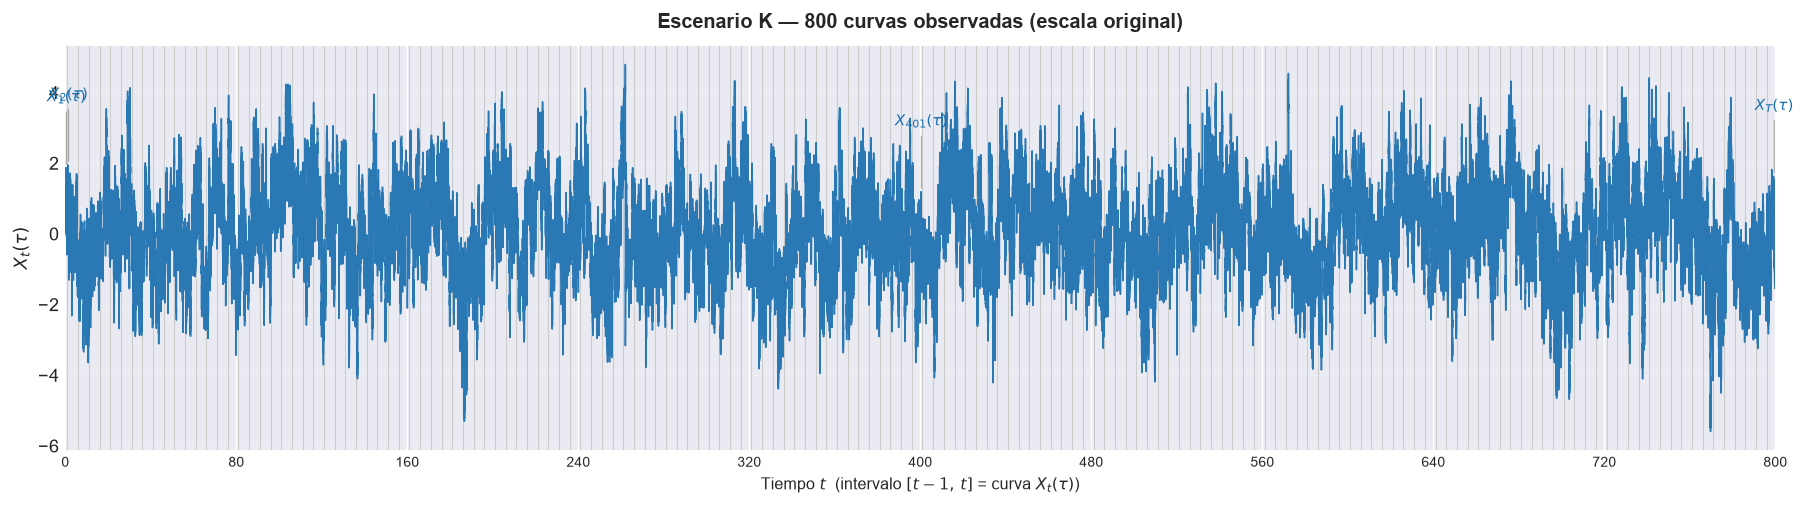

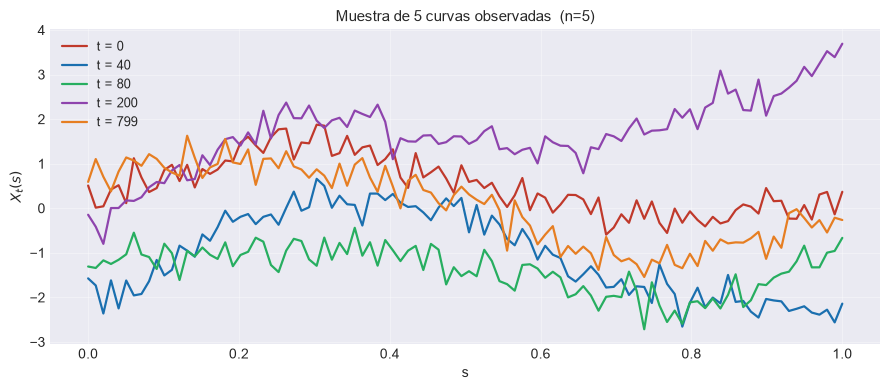

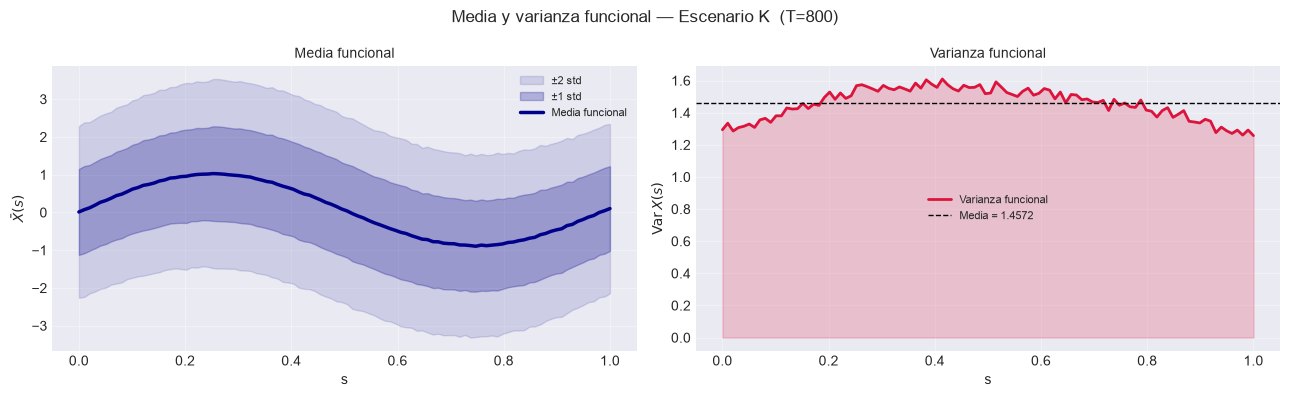

In [11]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario K — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario K")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()


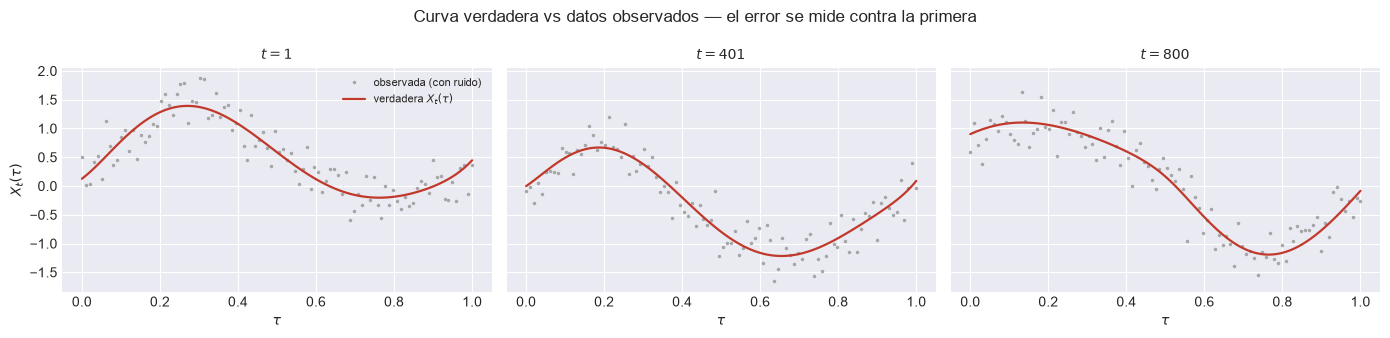

In [12]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()


### 2.6 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [13]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 3 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 3 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 3 directorios)


### 2.7 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [14]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 560]      → (560, 100)
prueba        : t ∈ [561, 800]  → (240, 100)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,72.9566%,0.601504,1.241458,0.396658
1,3,2,80.5781%,0.512925,0.834652,0.290774
2,4,2,93.6754%,0.295837,0.507081,0.096672
3,5,2,95.2547%,0.257769,0.329974,0.074068
4,6,2,95.5788%,0.248831,0.308100,0.070484
5,7,2,95.7746%,0.243295,0.309821,0.068819
6,8,2,95.8684%,0.240578,0.302779,0.068762
7,9,2,95.9461%,0.238303,0.303318,0.068959
8,10,2,96.0055%,0.236529,0.299880,0.069468
9,11,2,96.0538%,0.235100,0.298883,0.070179



GCV mínimo → n_basis=7, order=4  (var retenida 95.8652%)


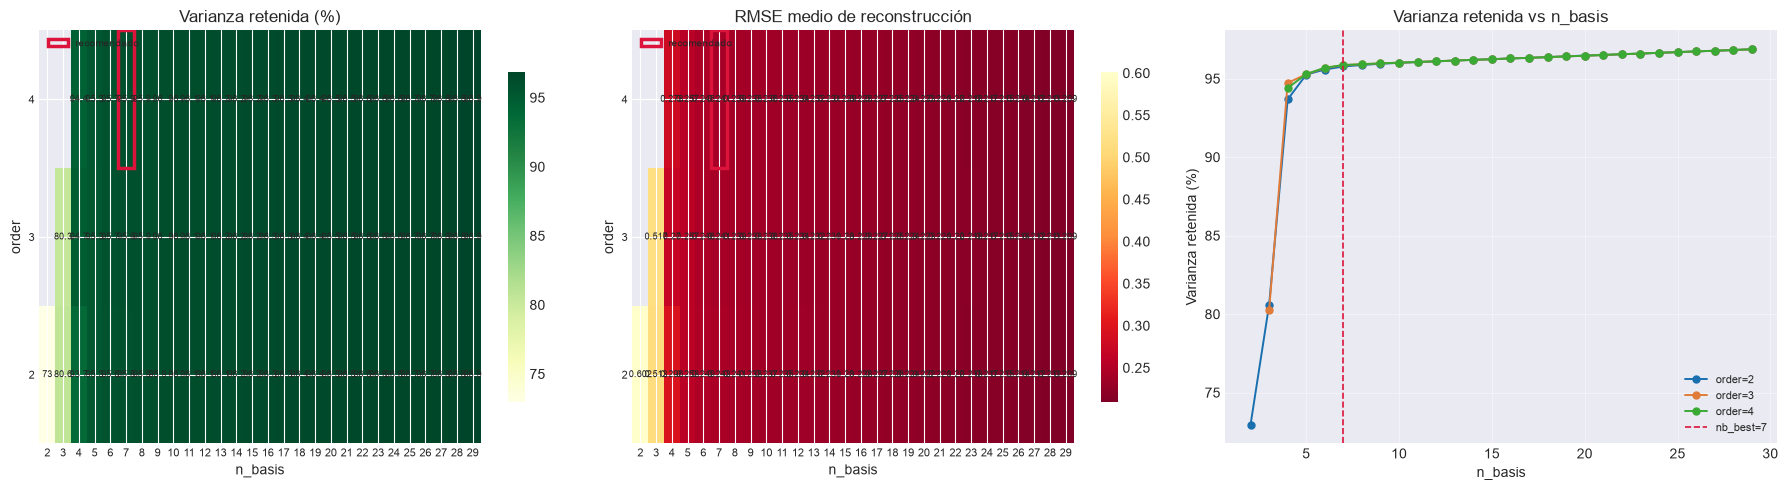

In [15]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=7, order=4
Sugerido GCV : n_basis=7, order=4   (coinciden)
THETA (800, 7)  (train=560, test=240)


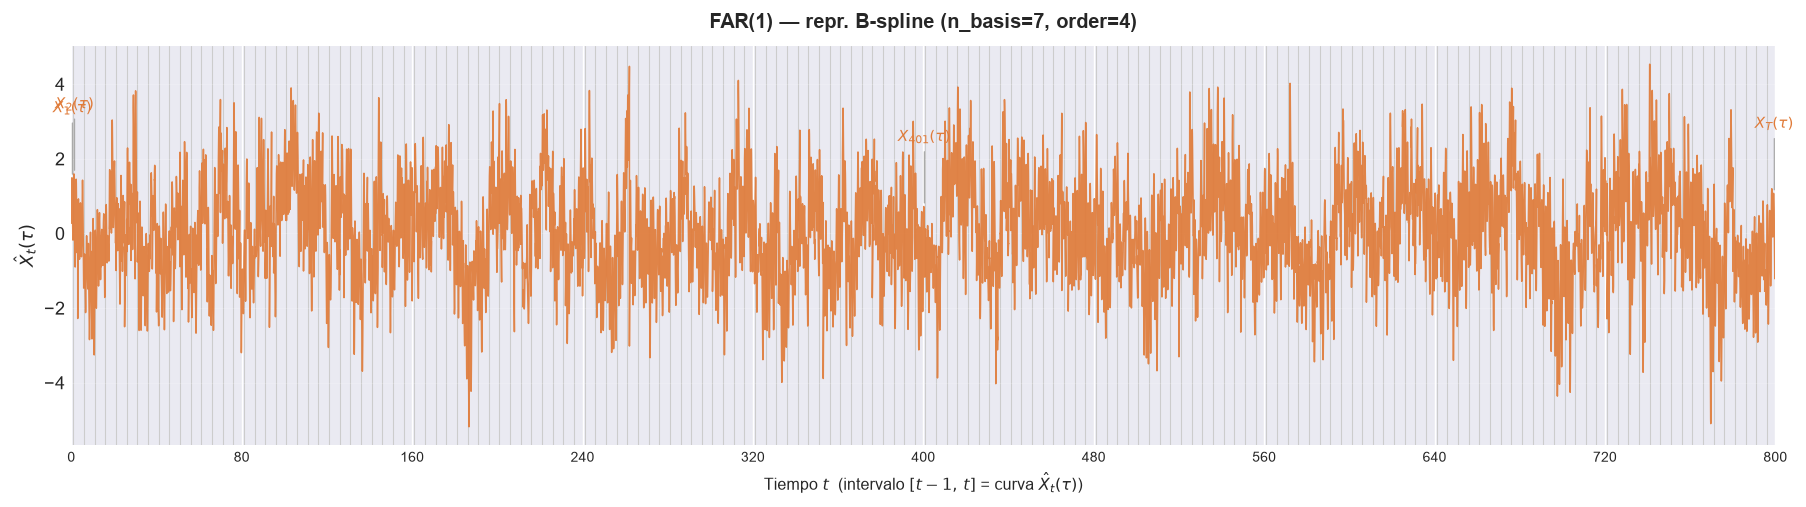

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 3 directorios)


In [16]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [17]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 7
  K                                  = 7
  n_ajuste                           = 560
  cond_W                             = 2.803e+01
  err_ortonormalidad_L2              = 2.776e-15
  err_ortonormalidad_gram            = 2.887e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 6.661e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 3.181e-16
  err_media_scores_rel               = 2.631e-15
  err_var_scores_vs_lambda           = 6.661e-16
  err_var_scores_vs_lambda_rel       = 2.010e-13
  err_correlacion_lag0               = 3.662e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,1.0488e+00,77.4295%,77.4295%,+0.615
1,2,1.9242e-01,14.2065%,91.6360%,+0.263
2,3,9.4052e-02,6.9438%,98.5798%,+0.034
3,4,1.2984e-02,0.9586%,99.5384%,+0.022
4,5,4.7720e-03,0.3523%,99.8907%,+0.038
5,6,8.1474e-04,0.0602%,99.9508%,-0.041
6,7,6.6576e-04,0.0492%,100.0000%,-0.033



K disponibles: 7   ·   sugerencia (var ≥ 95%): M = 3
  M=1: var. acum = 77.4295%  ·  sensibilidad
  M=2: var. acum = 91.6360%  ·  sensibilidad
  M=3: var. acum = 98.5798%  ·  regla del 95 %


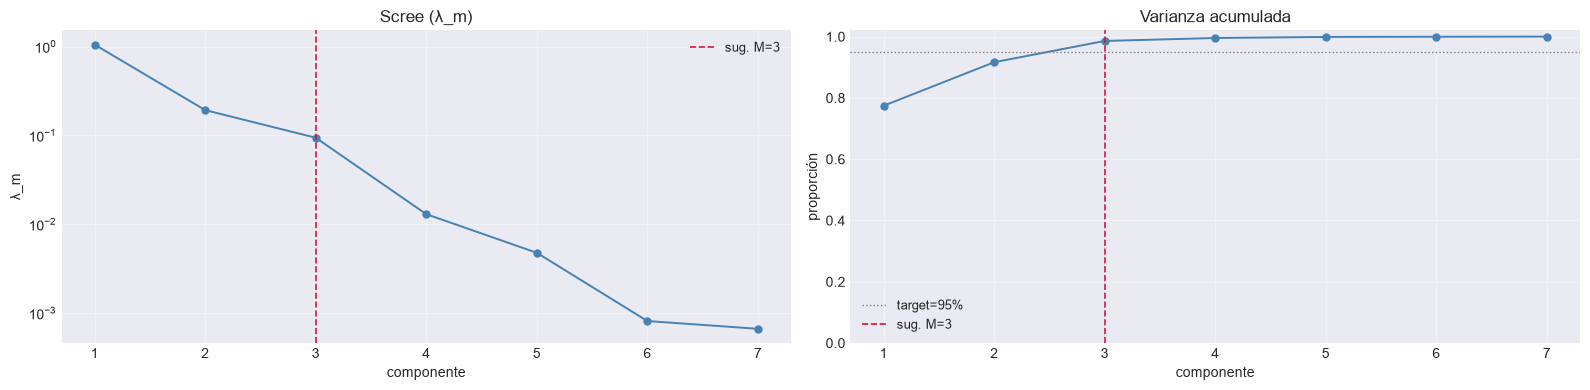

In [18]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido: no hay más de K componentes que retener.
# Con mu = sin(2 pi tau) el GCV eligió una base corta, de modo que los puntos
# altos del barrido caen en componentes que son en buena medida artefacto de
# esa base y no direcciones del proceso. Se advierte, no se oculta.
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

| Bloque | Qué hace |
|---|---|
| §4.1 | `set_M(M)` y scores; contraste con la regla del 95 % |
| §4.2 | estandarización (**sólo train**) y artefactos FPCA |
| §4.3 | diagnóstico de rezagos sobre el bloque de entrenamiento |
| §4.4 | orden AR y construcción de los datasets |
| §4.5 | hiperparámetros y `mcmc_config` — el contrato con MATLAB |
| §4.6 | `eval_config`, líneas base y `verificar_contrato` |

In [19]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    # M se declara en la celda [BARRIDO] de §1.1 porque forma parte del
    # EXPERIMENT_ID y las rutas se arman antes de llegar aquí. Aquí sólo se
    # consume y se contrasta con la regla del 95 % (M_SUGERIDO, de §3.3).
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Estandarización ------------------------------------------------
    # Se ajusta SÓLO con train y registra n_ajuste para que esa disciplina sea
    # auditable desde el artefacto y no una promesa del notebook. La ausencia
    # de fuga en el FPCA ya es propiedad de la clase (su fit vio sólo train);
    # aquí no se reajusta nada, sólo se trunca.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    SCORES_STD       = scores_standardizer.transform(SCORES)
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}")
    print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (~0)")
    print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (~0)")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi estandarizados"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    # Los rezagos del primer origen de prueba vienen del final del bloque de
    # entrenamiento: son observaciones pasadas disponibles en cada origen, de
    # modo que su uso es el condicionamiento de la predicción a h=1, no fuga.
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "standardized_zscore_ddof0",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparámetros y MCMC: el contrato con MATLAB -----------------
    # psbp_fd_iteracion.m lee estos valores del JSON y no los tiene escritos a
    # mano, incluida seed_base. Ojo con la doble acepción de M: dentro de
    # mcmc_config es el tamaño de la grilla de localización G* del
    # stick-breaking, NO el número de componentes FPCA; N es el truncamiento
    # del número de átomos.
    def _clasificar(nombre, k_modelo):
        return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
                else "cross_lag")

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        tipos = [_clasificar(nm, k) for nm in cov_names]
        vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "apij": vals[:, 0], "bpij": vals[:, 1],
            "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
        print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
        for j, nm in enumerate(cov_names):
            a, b = hp["apij"][j], hp["bpij"][j]
            marca = "  <" if _clasificar(nm, k) == "own_lag1" else ""
            print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
                  f"{a/(a+b):>7.3f}{marca}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "standardized_zscore_ddof0",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    # objetivo_evaluacion y modo_residuo se declaran aquí porque cambian el
    # significado de toda la evaluación y no deben quedar como una decisión
    # implícita del notebook _04. Son idénticos entre puntos del barrido, y
    # 34_04 lo exige con assert.
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "standardized_zscore_ddof0",
        # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
        #   curva_verdadera + modo_residuo "ninguno" => la banda cubre la curva
        #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau). Lo
        #   que queda fuera es truncamiento FPCA puro, sin el ruido de medición.
        "objetivo_evaluacion": "curva_verdadera",
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
        "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
        "metrics_curvas": ["MISE", "RMSE_funcional"],
        "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_true, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva VERDADERA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_names)),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

N_LAGS      : 1
MCMC_CONFIG : {'nsim': 2500, 'burn': 500, 'N': 35, 'M': 35}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (2500 - 500) x 2 = 4000

M = 1   ·   escenario_K_1_r01_m01
M(95 %) según la regla : 3   (K disponible = 7)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 77.4295%
[train] max|media xi| = 7.30e-17   (~ 0)
[test]  max|media xi| = 0.003
[test]  var xi / lambda = [1.11]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 1)
  [train] max|media| = 3.17e-18  (~0)
  [train] max|std-1| = 0.00e+00  (~0)
  [test]  media = [-0.003]
  [test]  std   = [1.052]

[functional] artefactos FPCA · cond_W = 2.803e+01


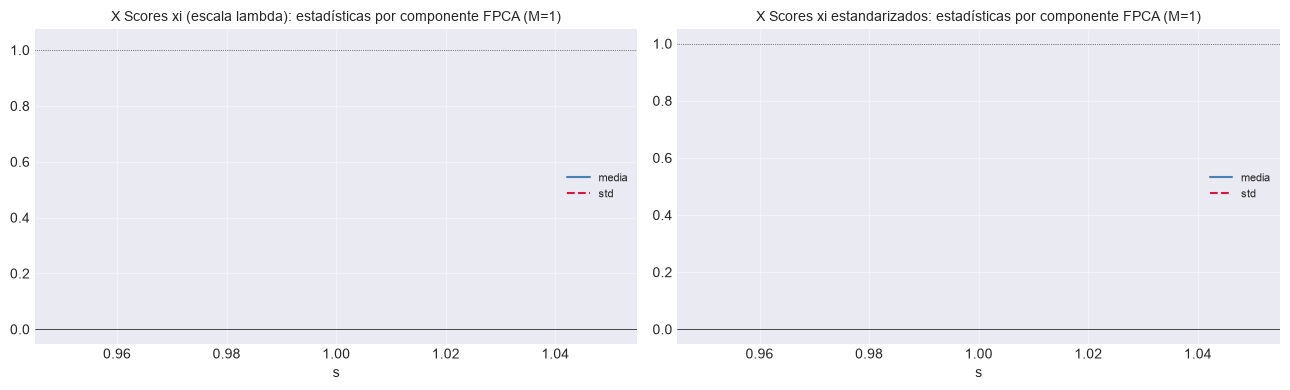

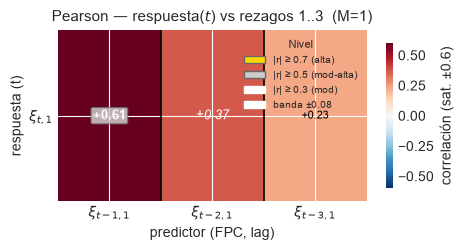

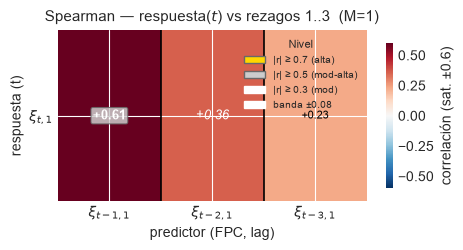

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (559, 2) · test (240, 2)

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_K_1_r01_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,240.0000,1.0523,1.0523,-0.0000,1.4993,1.2245
persistencia_lag1,240.0000,0.8549,0.8549,0.3400,1.1054,1.0514


contrato_ok = True   (M=1, K=7, T0=560, n_components=1)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_K_1_r01_m02
M(95 %) según la regla : 3   (K disponible = 7)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 91.6360%
[train] max|media xi| = 3.18e-16   (~ 0)
[test]  max|media xi| = 0.051
[test]  var xi / lambda = [1.11  1.176]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 2)
  [train] max|media| = 3.68e-17  (~0)
  [train] max|std-1| = 4.44e-16  (~0)
  [test]  media = [-0.003 -0.116]
  [test]  std   = [1.052 1.083]

[functional] artefactos FPCA · cond_W = 2.803e+01


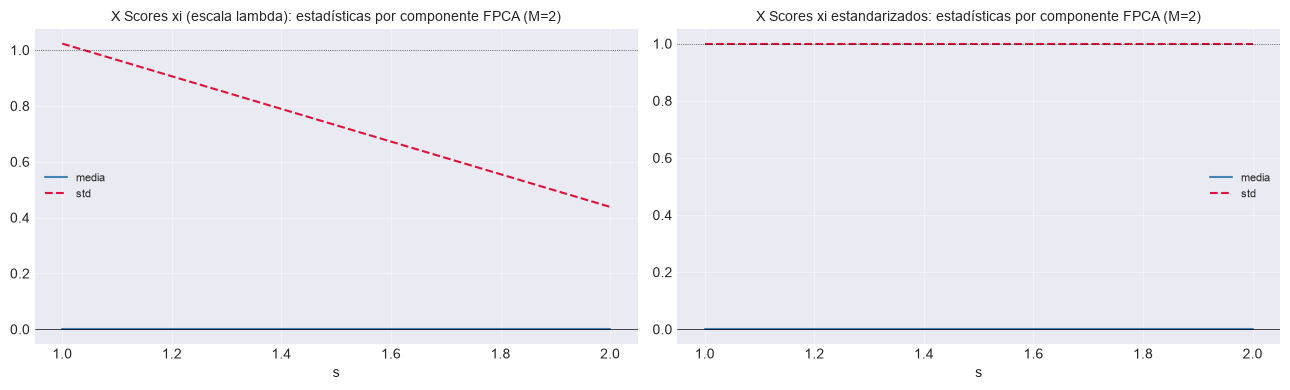

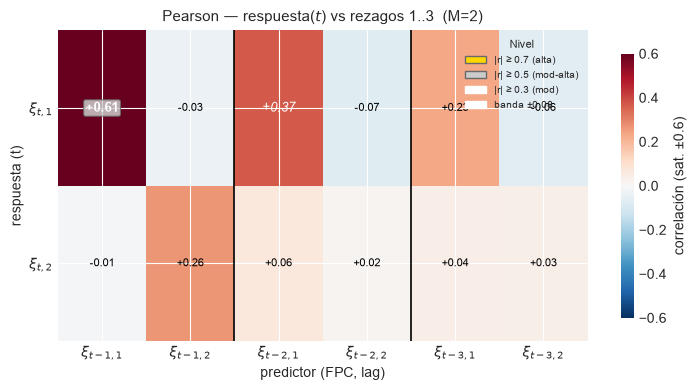

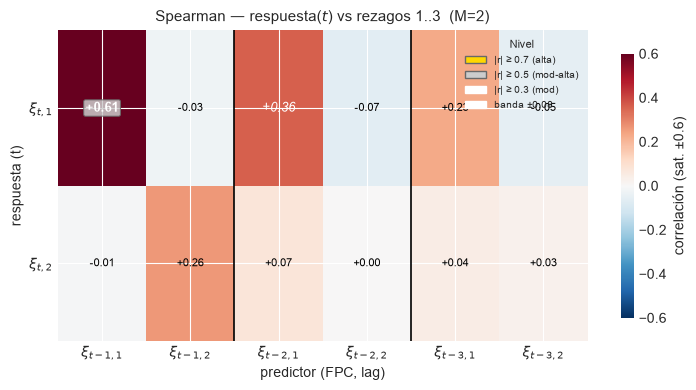

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (559, 3) · test (240, 3)
  fpc_2: train (559, 3) · test (240, 3)

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_2_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_K_1_r01_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,240.0000,1.0523,1.0893,1.0708,-0.0057,1.4993,1.2245
persistencia_lag1,240.0000,0.8549,1.3327,1.0938,-0.0869,1.2190,1.1041


contrato_ok = True   (M=2, K=7, T0=560, n_components=2)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_K_1_r01_m03
M(95 %) según la regla : 3   (K disponible = 7)
M de este punto        : 3   (coincide con la regla)
M = 3   var. explicada = 98.5798%
[train] max|media xi| = 3.18e-16   (~ 0)
[test]  max|media xi| = 0.051
[test]  var xi / lambda = [1.11  1.176 1.06 ]
[holdout] ajustado con 560 filas = T0 (train[1:560]) -> ok=True

SCORES_STD (800, 3)
  [train] max|media| = 4.79e-17  (~0)
  [train] max|std-1| = 4.44e-16  (~0)
  [test]  media = [-0.003 -0.116 -0.021]
  [test]  std   = [1.052 1.083 1.028]

[functional] artefactos FPCA · cond_W = 2.803e+01


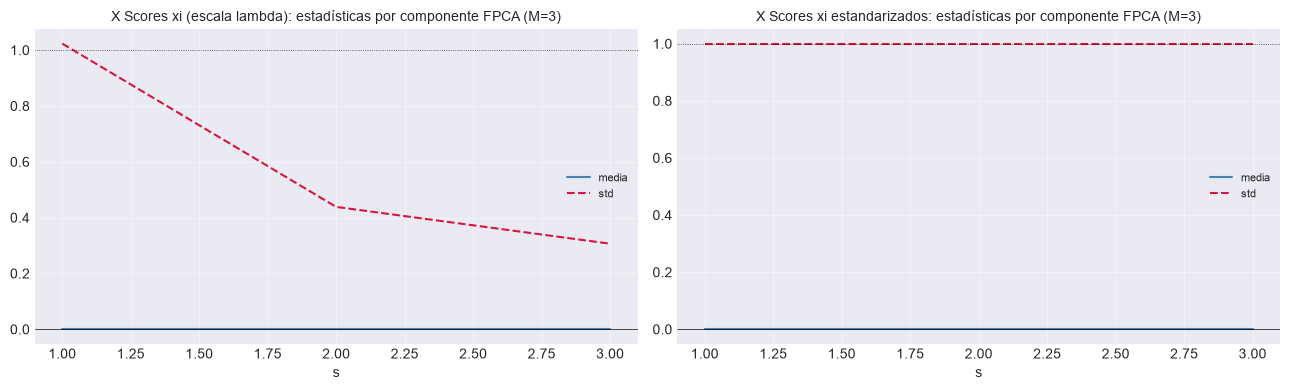

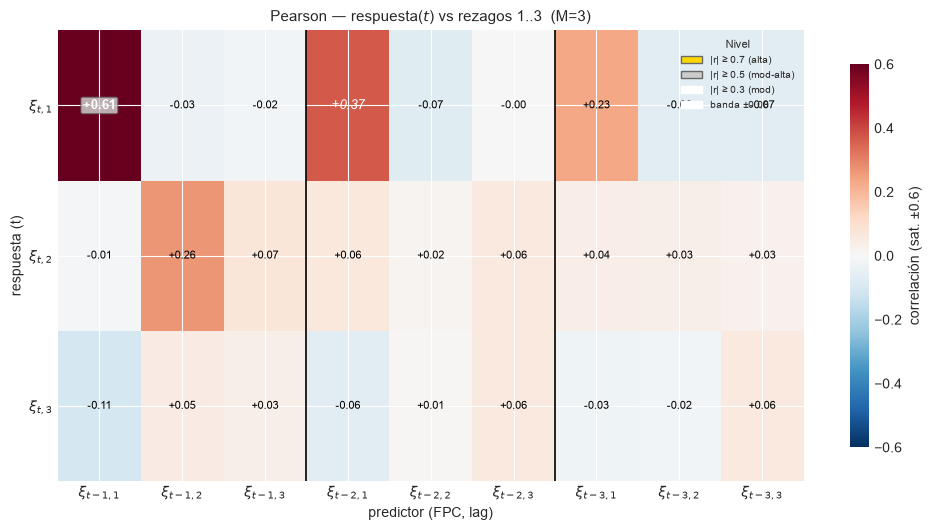

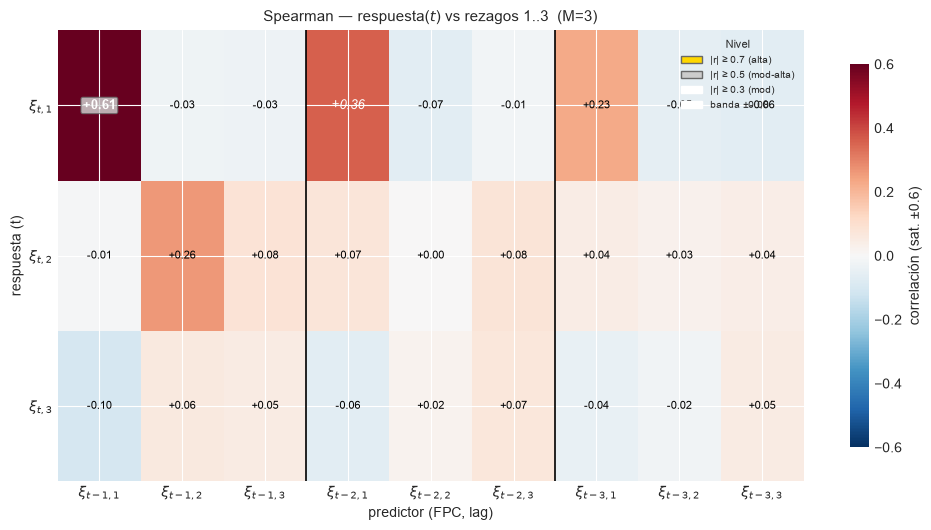

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 559   n_test_eff : 240
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (559, 4) · test (240, 4)
  fpc_2: train (559, 4) · test (240, 4)
  fpc_3: train (559, 4) · test (240, 4)

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M

Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo         

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,240.0000,1.0523,1.0893,1.0287,1.0568,-0.0039,1.4993,1.2245
persistencia_lag1,240.0000,0.8549,1.3327,1.3487,1.1788,-0.2978,1.2881,1.1350


contrato_ok = True   (M=3, K=7, T0=560, n_components=3)
estandarizador ajustado con 560 filas (T0=560)
verificación FPCA: todo_ok = True


In [20]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
N_LAGS      = 1
MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": 35, "M": 35}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [21]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{' '.join(str(m) for m in M_FPCA_LIST)}]  "
      f"(el mismo de 34_03, 34_04 y 34_05)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_K_1_r01_m01,77.4295%,7,False,1,1,True
2,escenario_K_1_r01_m02,91.6360%,7,False,2,2,True
3,escenario_K_1_r01_m03,98.5798%,7,True,3,3,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1 2 3]  (el mismo de 34_03, 34_04 y 34_05)
